# Projeto 03: Multimodalidade  
**Dataset Escolhido:** [Multimodal Hate Speech](https://www.kaggle.com/datasets/victorcallejasf/multimodal-hate-speech)  
**Grupo:** H  
**Alunos:** Lucas de Oliveira Ferreira / Luis Enrique Asuncion Velasquez  

## Visão Geral do Dataset
O Multimodal Hate Speech Dataset (MMHS150K) é um conjunto de dados multimodal composto por 150 mil tweets, cada um contendo:

* texto do tweet
* imagem associada
* anotações de 3 avaliadores humanos
* texto extraído da imagem (OCR)

O objetivo é permitir pesquisas em detecção multimodal de discurso de ódio.

## Instalando e Importando Bibliotecas

In [ ]:
!pip install -q transformers torchvision scikit-learn

In [ ]:
!pip install kagglehub

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub
import os
import json

In [ ]:
path = kagglehub.dataset_download("victorcallejasf/multimodal-hate-speech")

print("Path to dataset files:", path)

100%|██████████| 5.97G/5.97G [03:27<00:00, 30.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/victorcallejasf/multimodal-hate-speech/versions/1


## Estrutura do Dataset
O dataset contém os seguintes diretórios/arquivos:

* img_resized/ → 150.000 imagens (lado mínimo ≥ 500 px)
* img_txt/ → texto extraído das imagens usando OCR.
* splits/ → listas de IDs para train/val/test
* MMHS150K_GT.json → metadados dos tweets
* hatespeech_keywords.txt → palavras usadas para coleta no Twitter

In [ ]:
print("Arquivos:")
for item in os.listdir(path):
    print("-", item)

Arquivos:
- splits
- img_resized
- img_txt
- hatespeech_keywords.txt
- MMHS150K_readme.txt
- MMHS150K_GT.json


In [ ]:
json_path = os.path.join(path, "MMHS150K_GT.json")

with open(json_path, "r") as f:
    data = json.load(f)

print("Número de tweets no dataset", len(data))

Número de tweets no dataset 149823


In [ ]:
tweet_ids = list(data.keys())

print("Primeiros 5 IDs de tweets:")
print(tweet_ids[:5])

Primeiros 5 IDs de tweets:
['1114679353714016256', '1063020048816660480', '1108927368075374593', '1114558534635618305', '1035252480215592966']


In [ ]:
sample_id = tweet_ids[0]
print("Exemplo de entrada para o tweet", sample_id)
print(json.dumps(data[sample_id], indent=2)[:1000])

Exemplo de entrada para o tweet 1114679353714016256
{
  "img_url": "http://pbs.twimg.com/tweet_video_thumb/D3gi9MHWAAAgfl7.jpg",
  "labels": [
    4,
    1,
    3
  ],
  "tweet_url": "https://twitter.com/user/status/1114679353714016256",
  "tweet_text": "@FriskDontMiss Nigga https://t.co/cAsaLWEpue",
  "labels_str": [
    "Religion",
    "Racist",
    "Homophobe"
  ]
}


## Anotações
Cada tweet possui três rótulos (0–5), atribuídos por avaliadores da Amazon Mechanical Turk:

| ID | Classe    |
| -- | --------- |
| 0  | NotHate   |
| 1  | Racist    |
| 2  | Sexist    |
| 3  | Homophobe |
| 4  | Religion  |
| 5  | OtherHate |

A etiqueta final foi definida via moda (“majority vote”).

In [ ]:
rows = []

for tweet_id, info in data.items():
    row = {
        "tweet_id": tweet_id,
        "tweet_text": info.get("tweet_text", ""),
        "img_url": info.get("img_url", ""),
        "tweet_url": info.get("tweet_url", ""),
        "labels": info.get("labels", []),
        "labels_str": info.get("labels_str", [])
    }

    rows.append(row)

df = pd.DataFrame(rows)

print("Shape: ", df.shape)
df.head()

Shape:  (149823, 6)


,tweet_id,tweet_text,img_url,tweet_url,labels,labels_str
0,1114679353714016256,@FriskDontMiss Nigga https://t.co/cAsaLWEpue,http://pbs.twimg.com/tweet_video_thumb/D3gi9MH...,https://twitter.com/user/status/11146793537140...,"[4, 1, 3]","[Religion, Racist, Homophobe]"
1,1063020048816660480,My horses are retarded https://t.co/HYhqc6d5WN,http://pbs.twimg.com/ext_tw_video_thumb/106301...,https://twitter.com/user/status/10630200488166...,"[5, 5, 5]","[OtherHate, OtherHate, OtherHate]"
2,1108927368075374593,“NIGGA ON MA MOMMA YOUNGBOY BE SPITTING REAL S...,http://pbs.twimg.com/media/D2OzhzHUwAADQjd.jpg,https://twitter.com/user/status/11089273680753...,"[0, 0, 0]","[NotHate, NotHate, NotHate]"
3,1114558534635618305,RT xxSuGVNGxx: I ran into this HOLY NIGGA TODA...,http://pbs.twimg.com/ext_tw_video_thumb/111401...,https://twitter.com/user/status/11145585346356...,"[1, 0, 0]","[Racist, NotHate, NotHate]"
4,1035252480215592966,“EVERYbody calling you Nigger now!” https://t....,http://pbs.twimg.com/media/Dl30pGIU8AAVGxO.jpg,https://twitter.com/user/status/10352524802155...,"[1, 0, 1]","[Racist, NotHate, Racist]"


In [ ]:
from statistics import mode

def get_majority_label(label_list):
    try:
        return mode(label_list)
    except:
        return label_list[0]

df["final_label"] = df["labels"].apply(get_majority_label)

df[["labels", "final_label"]].head()

,labels,final_label
0,"[4, 1, 3]",4
1,"[5, 5, 5]",5
2,"[0, 0, 0]",0
3,"[1, 0, 0]",0
4,"[1, 0, 1]",1


## Distribuição das Classes

O dataset é extremamente desbalanceado:

* 0 – NotHate: 116.790
* 1 – Racist: 14.183
* 5 – OtherHate: 8.196
* 2 – Sexist: 5.375
* 3 – Homophobe: 4.926
* 4 – Religion: 353

O discurso de ódio representa apenas ~22% do dataset.

In [ ]:
labels = {
    0 : "Not Hate",
    1 : "Racist",
    2 : "Sexist",
    3 : "Homophobe",
    4 : "Religion",
    5 : "Other Hate",
}

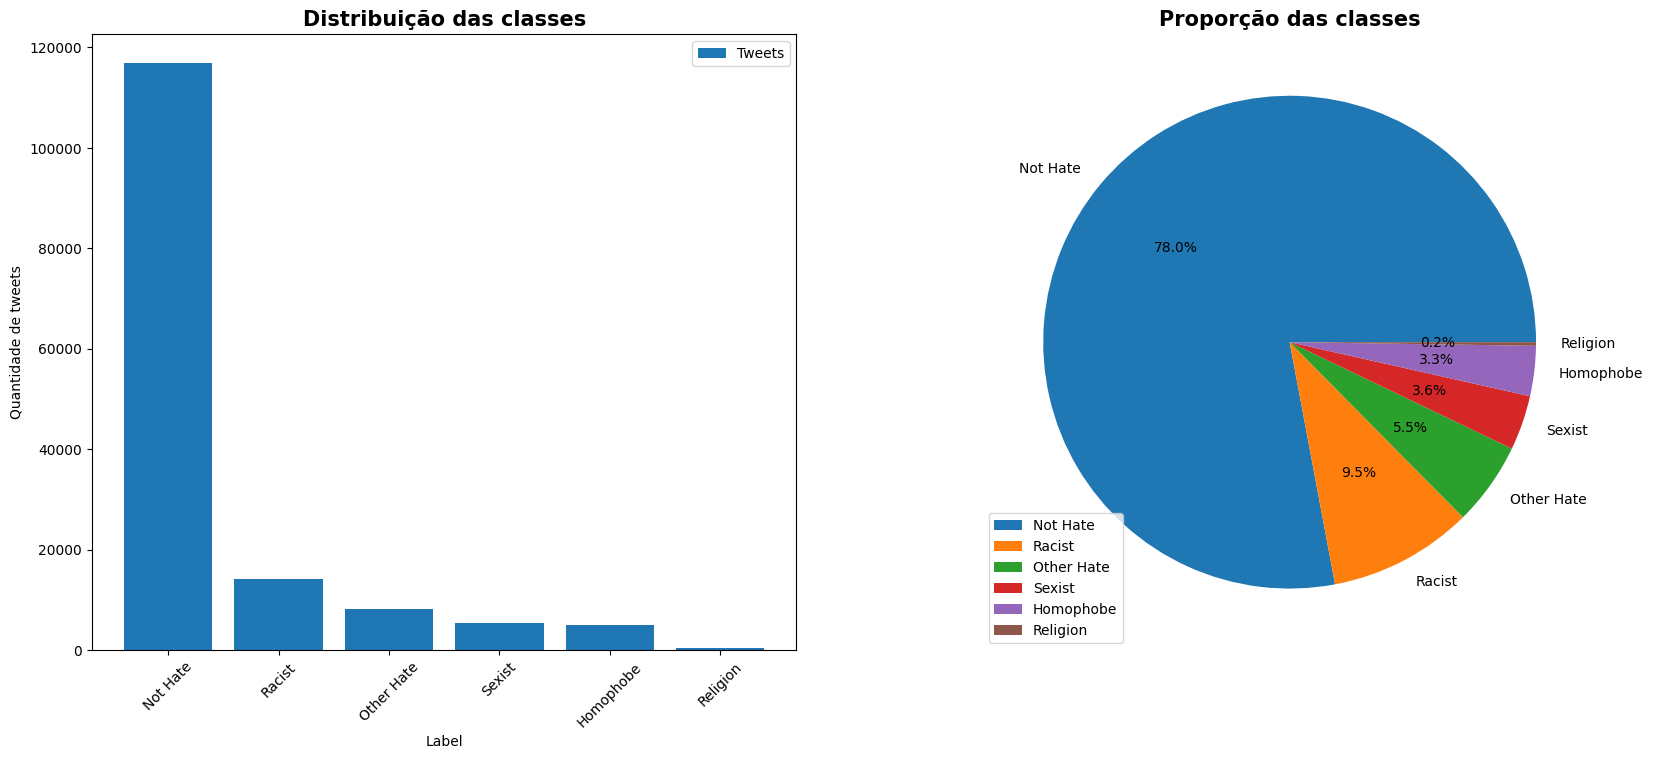

In [ ]:
counts = df["final_label"].map(labels).value_counts()

plt.figure(figsize=(20, 8))

plt.subplot(1, 2, 1)
plt.bar(counts.index, counts.values)
plt.title("Distribuição das classes", fontweight='bold', size = 15)
plt.xlabel("Label")
plt.ylabel("Quantidade de tweets")
plt.xticks(rotation = 45)
plt.legend(["Tweets"])

plt.subplot(1, 2, 2)
plt.pie(
    counts.values,
    labels=counts.index,
    autopct="%1.1f%%",
)
plt.title("Proporção das classes", fontweight='bold', size = 15)
plt.legend(counts.index, loc="best")


plt.show()

In [ ]:
df["text_len"] = df["tweet_text"].apply(lambda x: len(str(x).split()))
df["text_len"].describe()

,text_len
count,149823.000000
mean,11.511464
std,5.148600
min,2.000000
25%,7.000000
50%,11.000000
75%,15.000000
max,38.000000


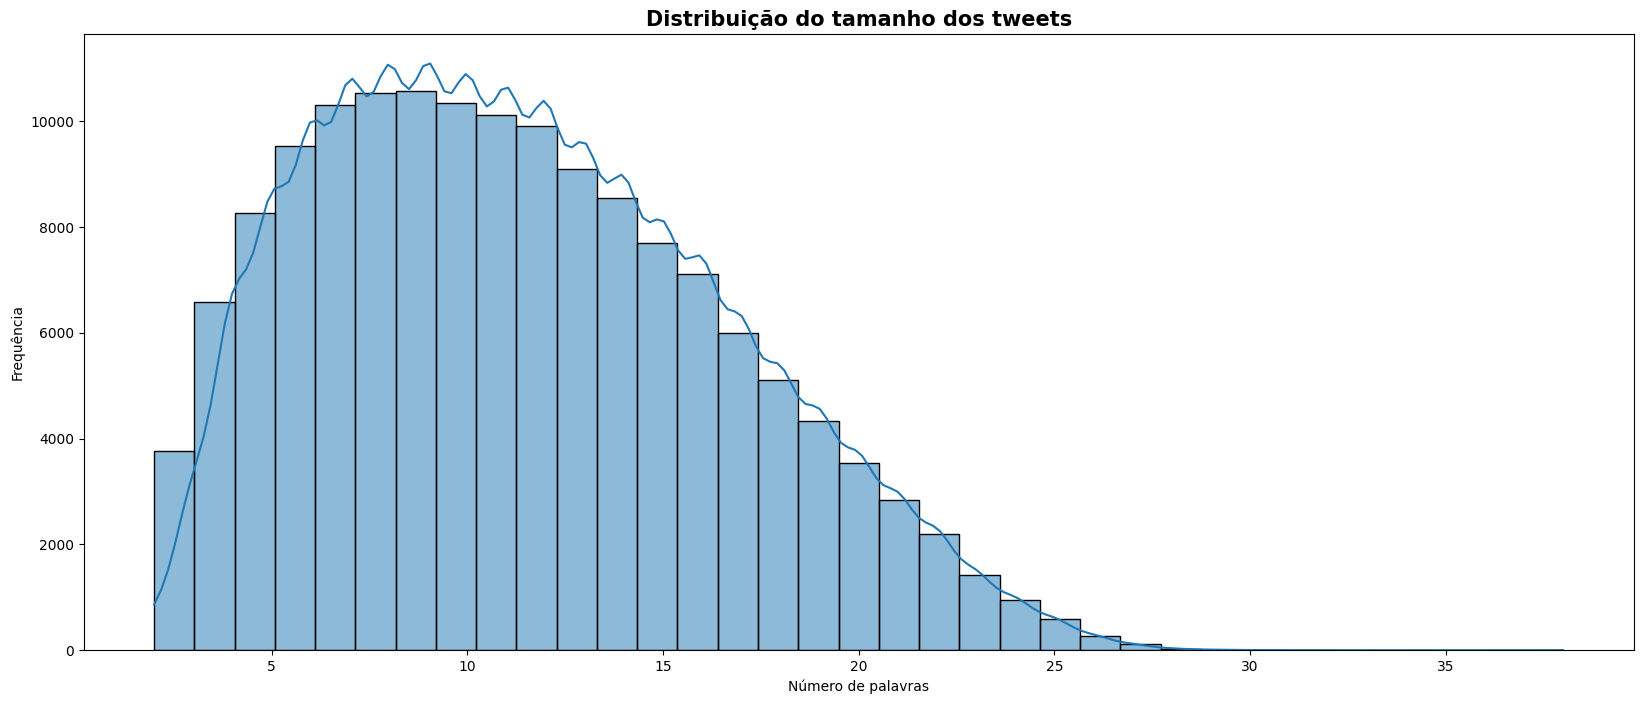

In [ ]:
plt.figure(figsize=(20,8))
sns.histplot(df["text_len"], bins=35, kde=True)
plt.title("Distribuição do tamanho dos tweets", fontweight='bold', size = 15)
plt.xlabel("Número de palavras")
plt.ylabel("Frequência")
plt.show()

## Análise Textual dos Tweets
✔ Limpeza textual aplicada:
* lower
* remoção de URLs, menções, números e emojis
* tokenização
* remoção de stopwords

✔ Estatísticas gerais:
* média: 11,5 palavras por tweet
* máximo: 38 palavras

✔ Principais achados:
* insultos aparecem mesmo na classe NotHate → ruído semântico alto
* classes ofensivas possuem padrões linguísticos claros
* TF-IDF mostrou que cada classe tem suas palavras discriminativas

In [ ]:
!pip install nltk
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 9.9 MB/s eta 0:00:00


In [ ]:
import nltk
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
import re
import emoji
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words("english"))

def clean_text(t):
    t = t.lower()
    t = re.sub(r"\brt\b", "", t)
    t = re.sub(r"http\S+", "", t)
    t = re.sub(r"@\w+", "", t)
    t = re.sub(r"#\w+", "", t)
    t = emoji.replace_emoji(t, replace="")
    t = re.sub(r"[^a-z\s]", "", t)
    t = re.sub(r"\s+", " ", t).strip()

    tokens = word_tokenize(t)
    tokens = [w for w in tokens if w not in stop_words]

    return " ".join(tokens)

df["clean_text"] = df["tweet_text"].apply(clean_text)
df[["tweet_text", "clean_text"]].head()

,tweet_text,clean_text
0,@FriskDontMiss Nigga https://t.co/cAsaLWEpue,nigga
1,My horses are retarded https://t.co/HYhqc6d5WN,horses retarded
2,“NIGGA ON MA MOMMA YOUNGBOY BE SPITTING REAL S...,nigga momma youngboy spitting real shit nigga
3,RT xxSuGVNGxx: I ran into this HOLY NIGGA TODA...,xxsugvngxx ran holy nigga today
4,“EVERYbody calling you Nigger now!” https://t....,everybody calling nigger


In [ ]:
from collections import Counter

all_words = " ".join(df["clean_text"]).split()
word_freq = Counter(all_words)

word_freq.most_common(20)

[('nigga', 79608),
 ('cunt', 14306),
 ('like', 11215),
 ('im', 9593),
 ('twat', 8030),
 ('dyke', 6831),
 ('ass', 6356),
 ('got', 6140),
 ('retarded', 5736),
 ('faggot', 5424),
 ('fuck', 5300),
 ('nigger', 5164),
 ('dont', 4935),
 ('get', 4702),
 ('shit', 4508),
 ('said', 4071),
 ('retard', 3781),
 ('look', 3688),
 ('u', 3574),
 ('real', 3537)]

In [ ]:
from collections import Counter

def top_words_by_class(label, n=20):
    subset = df[df["final_label"] == label]["clean_text"]
    words = " ".join(subset).split()
    freq = Counter(words)
    return freq.most_common(n)

for label in sorted(df["final_label"].unique()):
    print(f"\nTop palavras na classe {label}:")
    print(top_words_by_class(label))


Top palavras na classe 0:
[('nigga', 70094), ('cunt', 10389), ('like', 8989), ('im', 7669), ('twat', 6135), ('got', 5087), ('ass', 5084), ('dyke', 4793), ('fuck', 4088), ('dont', 3934), ('shit', 3696), ('get', 3659), ('said', 3387), ('retarded', 3082), ('real', 3044), ('look', 2809), ('u', 2774), ('know', 2654), ('aint', 2596), ('really', 2575)]

Top palavras na classe 1:
[('nigga', 7980), ('nigger', 2751), ('white', 1150), ('like', 1009), ('trash', 902), ('im', 857), ('got', 650), ('ass', 644), ('fuck', 523), ('dont', 507), ('get', 507), ('shit', 464), ('redneck', 439), ('said', 430), ('cunt', 391), ('card', 369), ('bitch', 349), ('race', 349), ('u', 346), ('say', 327)]

Top palavras na classe 2:
[('cunt', 2438), ('twat', 1033), ('nigga', 871), ('like', 322), ('fuck', 283), ('full', 274), ('fucking', 251), ('im', 241), ('ass', 220), ('dyke', 214), ('big', 210), ('milf', 209), ('faggot', 208), ('babe', 183), ('bitch', 171), ('get', 147), ('look', 145), ('dick', 135), ('got', 128), ('w

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

texts_by_class = {
    label: df[df["final_label"] == label]["clean_text"].tolist()
    for label in sorted(df["final_label"].unique())
}

In [ ]:
plt.figure(figsize=(14,8))
plt.

## WordClouds por Classe
A análise visual mostrou:

* Racist → termos como nigger, white, redneck
* Sexist → cunt, twat, milf
* Homophobe → faggot, dyke
* Religion → islam, muslim, terrorism
* OtherHate → retarded, hillbilly, sjw

O texto carrega a maior parte do sinal do discurso de ódio.

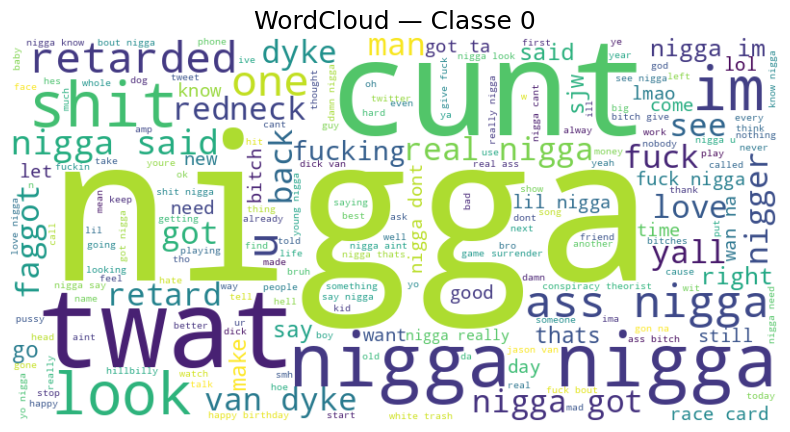

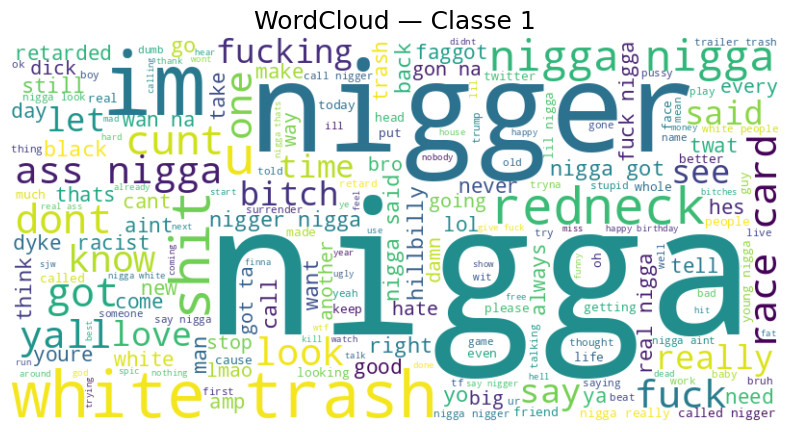

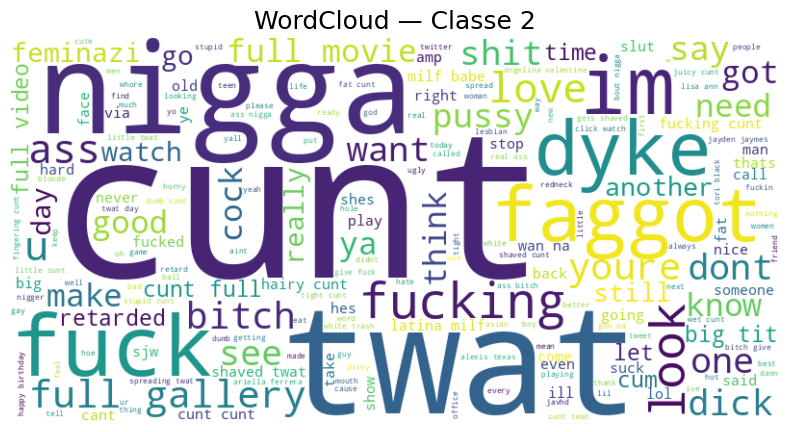

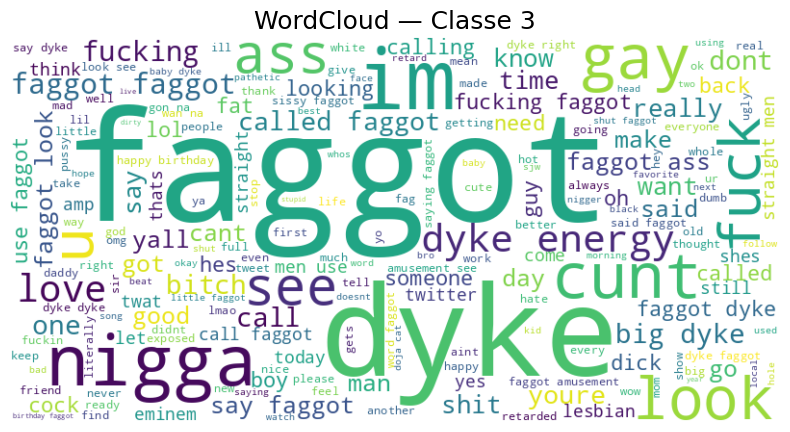

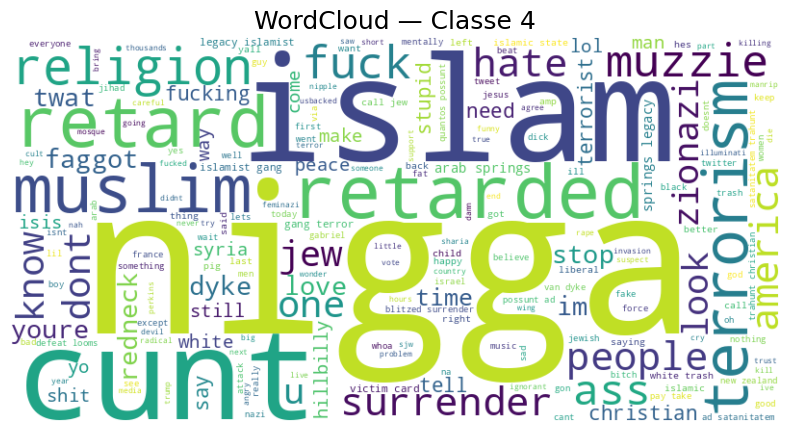

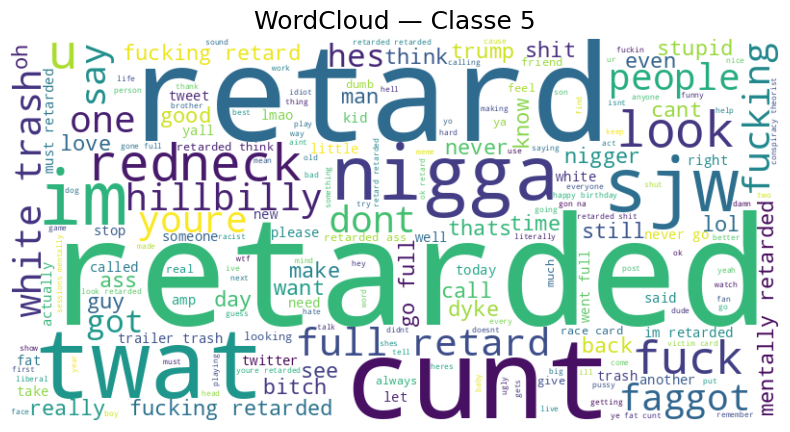

In [ ]:
from wordcloud import WordCloud

def plot_wordcloud(text, title):
    wc = WordCloud(
        width=800,
        height=400,
        background_color="white"
    ).generate(text)

    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title, fontsize=18)
    plt.show()

for label in sorted(df["final_label"].unique()):
    text = " ".join(texts_by_class[label])
    plot_wordcloud(text, f"WordCloud — Classe {label}")

## Análise das Imagens

✔ Integridade

* Todos os 149.823 tweets possuem imagem correspondente.

✔ Resoluções obtidas em 5.000 exemplos:

* média: 642 × 611 px
* mínimo: 500 px
* máximo: 2843 × 1542 px

✔ Exemplos por classe

* A maioria das imagens não contém conteúdo ofensivo visual explícito.
São fotos, memes, screenshots ou imagens aleatórias.

O componente visual raramente define a classe sozinho.

In [ ]:
import os

img_dir = os.path.join(path, "img_resized")
print("Pasta de imagens:", img_dir)

img_files = os.listdir(img_dir)
print("Número de arquivos na pasta img_resized:", len(img_files))

print("\nPrimeiros 5 arquivos de imagem:")
print(img_files[:5])

Pasta de imagens: /kaggle/input/multimodal-hate-speech/img_resized
Número de arquivos na pasta img_resized: 150000

Primeiros 5 arquivos de imagem:
['1061004551396999171.jpg', '1113139193524506624.jpg', '1114586062834339840.jpg', '1116515797399220225.jpg', '1108450061892108289.jpg']


In [ ]:
img_ids = {fname.split('.')[0] for fname in img_files}

df["has_image"] = df["tweet_id"].astype(str).isin(img_ids)

print(df["has_image"].value_counts())
df[["tweet_id", "has_image"]].head()

has_image
True    149823
Name: count, dtype: int64


,tweet_id,has_image
0,1114679353714016256,True
1,1063020048816660480,True
2,1108927368075374593,True
3,1114558534635618305,True
4,1035252480215592966,True


Imagen: 1107689390392987649.jpg
Tamaño: (895, 500)


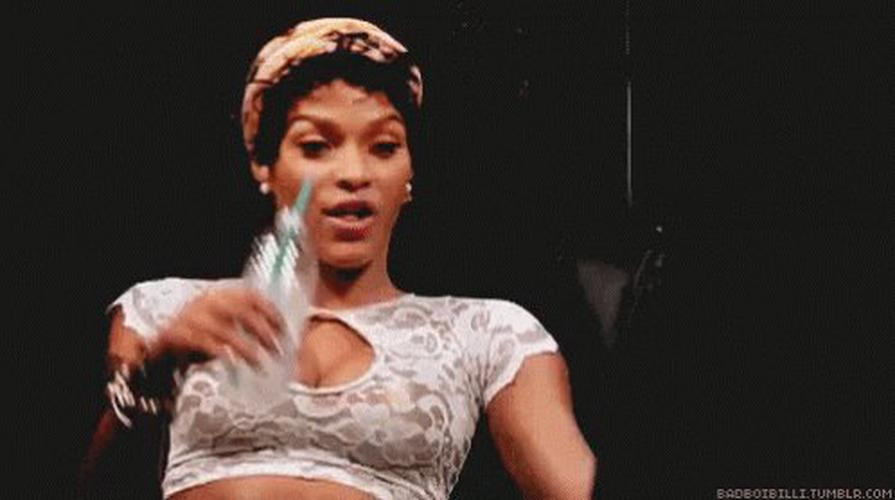

In [ ]:
from PIL import Image
import random

sample_img = random.choice(img_files)
img_path = os.path.join(img_dir, sample_img)

img = Image.open(img_path)
print("Imagen:", sample_img)
print("Tamaño:", img.size)
img

## Embeddings CLIP e Análise Visual
Usando CLIP (ViT-B/32):
* extraímos embeddings de 500 imagens
* reduzimos com PCA (2 componentes)

In [ ]:
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.8 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-k93r5q2o
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-k93r5q2o
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=c21db5a93fe0555193e3a77385239d6800d790e99a512f32b90c34c696eb18e3
  Stored in directory: /tmp/pip-ephem-wheel-cache-kw8pkjxo/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [ ]:
import torch
import clip
from PIL import Image

device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

subset_imgs = img_files[:500]

embeddings = []

for fname in subset_imgs:
    img_path = os.path.join(img_dir, fname)
    image = preprocess(Image.open(img_path)).unsqueeze(0).to(device)
    with torch.no_grad():
        emb = model.encode_image(image)
    emb = emb.cpu().numpy().flatten()
    embeddings.append(emb)

embeddings = np.array(embeddings)
embeddings.shape

100%|███████████████████████████████████████| 338M/338M [00:05<00:00, 63.1MiB/s]


(500, 512)

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
points = pca.fit_transform(embeddings)

points[:5]

array([[ 1.91654101, -0.2566328 ],
       [ 3.33788404,  0.12993008],
       [-5.97440279,  1.25160775],
       [ 0.47445664,  3.33345859],
       [ 1.61298411, -2.34231749]])

Resultado:

* Os pontos ficaram altamente dispersos, sem clusters definidos.

Conclusão:

* As imagens do dataset são extremamente diversas e não apresentam padrões visuais que separem claramente as classes de ódio. O conteúdo visual sozinho não é suficiente para classificação.

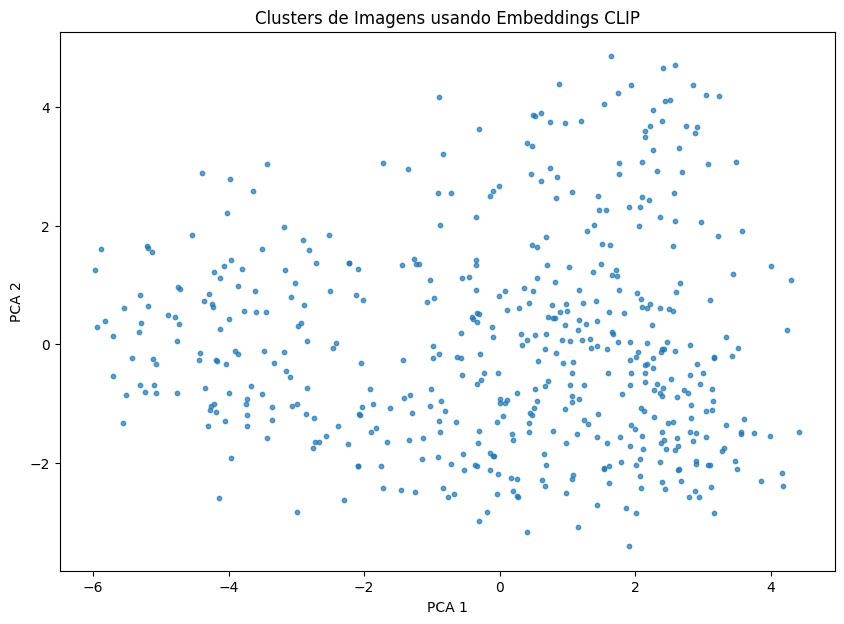

In [ ]:
plt.figure(figsize=(10,7))
plt.scatter(points[:,0], points[:,1], s=10, alpha=0.7)
plt.title("Clusters de Imagens usando Embeddings CLIP")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

## Análise OCR
* Apenas ~40% das imagens possuem OCR legível
* Na maioria dos casos, o texto da imagem NÃO tem relação com o tweet.

In [ ]:
ocr_dir = os.path.join(path, "img_txt")

def load_ocr_text(img_id):
    fname = img_id + ".json"
    full_path = os.path.join(ocr_dir, fname)

    if os.path.exists(full_path):
        try:
            with open(full_path, "r", encoding="utf-8", errors="ignore") as f:
                data = json.load(f)
                return data.get("img_text", "").strip()
        except:
            return ""
    return ""

df["ocr_text"] = df["tweet_id"].astype(str).apply(load_ocr_text)

In [ ]:
df[df["ocr_text"] != ""].sample(5)

,tweet_id,tweet_text,img_url,tweet_url,labels,labels_str,final_label,text_len,clean_text,has_image,ocr_text
36409,1113058901082210304,Can’t wait for Virgil to launch a ball up in t...,http://pbs.twimg.com/media/D3JhKNXU0AEJ62h.jpg,https://twitter.com/user/status/11130589010822...,"[0, 0, 0]","[NotHate, NotHate, NotHate]",0,22,cant wait virgil launch ball air twat bird tot...,True,ONAD TO DADE IC TOno
35479,1044326290549964800,@Slimelicker88 I thought Twitter acting retard...,http://pbs.twimg.com/media/Dn4xOaSUUAAdlQy.jpg,https://twitter.com/user/status/10443262905499...,"[0, 5, 3]","[NotHate, OtherHate, Homophobe]",0,10,thought twitter acting retarded,True,Retweeted by Mr. Lonely PJ @FenixPJ 1h RT @Vie...
118,1056654643579797505,stupid cunt. #dcfc #nffc https://t.co/Kgwa0rHKL4,http://pbs.twimg.com/media/Dqn9y4ZXQAI71Z9.jpg,https://twitter.com/user/status/10566546435797...,"[0, 0, 0]","[NotHate, NotHate, NotHate]",0,5,stupid cunt,True,"Dogs Nob @dogsnobrob All rivalry aside, events..."
143542,1113464723897556992,Full Movie: https://t.co/OLAdPV8dhA Pornstar b...,http://pbs.twimg.com/media/D3PSRB_WAAEKXUQ.jpg,https://twitter.com/user/status/11134647238975...,"[0, 2, 0]","[NotHate, Sexist, NotHate]",0,14,full movie pornstar babe big hooters angelina ...,True,RS.CO
38085,1106823043211509760,Why ain't this cunt dead yet he even did the h...,http://pbs.twimg.com/media/D1w5sArX4AAQHv5.jpg,https://twitter.com/user/status/11068230432115...,"[0, 0, 0]","[NotHate, NotHate, NotHate]",0,18,aint cunt dead yet even hand circle gesture he...,True,LIVE: Mosque attack suspect 'smirks' as he app...


# Treinamento e Avaliação (em progresso)

## Divisão Treino, Validação e Teste

In [ ]:
import os
import pandas as pd

# 1. carregar splits oficiais
splits_dir = os.path.join(path, "splits")

def load_ids(name):
    with open(os.path.join(splits_dir, f"{name}.txt")) as f:
        return set(l.strip() for l in f if l.strip())

df["tweet_id_str"] = df["tweet_id"].astype(str)

train_ids = load_ids("train_ids")
val_ids   = load_ids("val_ids")
test_ids  = load_ids("test_ids")

train_df = df[df["tweet_id_str"].isin(train_ids)].copy()
val_df   = df[df["tweet_id_str"].isin(val_ids)].copy()
test_df  = df[df["tweet_id_str"].isin(test_ids)].copy()

# 2. rótulos binário e multiclasse
for split in (train_df, val_df, test_df):
    split["y_bin"]   = (split["final_label"] > 0).astype(int)
    split["y_multi"] = split["final_label"].astype(int)

# 3. textos pré-processados
for split in (train_df, val_df, test_df):
    split["text_raw"]   = split["tweet_text"].fillna("").astype(str)     # p/ char n-grams
    split["text_clean"] = split.get("clean_text", split["tweet_text"]).fillna("").astype(str)


## Baseline Binária

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

# char n-grams TF-IDF no texto cru
char_vect = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5),
    min_df=5,
    max_features=200_000
)

X_train = char_vect.fit_transform(train_df["text_raw"])
X_val   = char_vect.transform(val_df["text_raw"])
X_test  = char_vect.transform(test_df["text_raw"])

y_train = train_df["y_bin"].values
y_val   = val_df["y_bin"].values
y_test  = test_df["y_bin"].values

clf_bin = LinearSVC(class_weight="balanced")
clf_bin.fit(X_train, y_train)

print("=== Binário - Validação ===")
print(classification_report(y_val, clf_bin.predict(X_val), target_names=["NotHate", "Hate"], digits=4))

print("=== Binário - Teste ===")
print(classification_report(y_test, clf_bin.predict(X_test), target_names=["NotHate", "Hate"], digits=4))


=== Binário - Validação ===
              precision    recall  f1-score   support

     NotHate     0.6352    0.7844    0.7020      2755
        Hate     0.6283    0.4472    0.5225      2245

    accuracy                         0.6330      5000
   macro avg     0.6317    0.6158    0.6122      5000
weighted avg     0.6321    0.6330    0.6214      5000

=== Binário - Teste ===
              precision    recall  f1-score   support

     NotHate     0.6417    0.7701    0.7000      5573
        Hate     0.6131    0.4585    0.5247      4427

    accuracy                         0.6322     10000
   macro avg     0.6274    0.6143    0.6124     10000
weighted avg     0.6290    0.6322    0.6224     10000



## Baseline Multiclasse

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV, StratifiedKFold

X_train_m = X_train   # reaproveita o mesmo char TF-IDF
X_val_m   = X_val
X_test_m  = X_test

y_train_m = train_df["y_multi"].values
y_val_m   = val_df["y_multi"].values
y_test_m  = test_df["y_multi"].values

label_names = {
    0: "NotHate",
    1: "Racist",
    2: "Sexist",
    3: "Homophobe",
    4: "Religion",
    5: "OtherHate"
}
targets = [label_names[i] for i in sorted(label_names)]

# ====== Modelo "mais forte": SVM com busca de hiperparâmetros ======

base_clf = LinearSVC(class_weight="balanced")

param_grid = {
    "C": [0.01, 0.1, 1.0, 10.0]  # ajuste/expanda essa grade se quiser
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid = GridSearchCV(
    estimator=base_clf,
    param_grid=param_grid,
    scoring="f1_macro",   # bom para classes desbalanceadas
    cv=cv,
    n_jobs=-1,
    verbose=1
)

print("=== Ajustando hiperparâmetros (GridSearchCV) ===")
grid.fit(X_train_m, y_train_m)

print(f"Melhor parâmetro C: {grid.best_params_['C']}")
print(f"Melhor f1_macro (cv): {grid.best_score_:.4f}")

# Modelo final com melhor C encontrado
clf_multi = grid.best_estimator_

# ====== Avaliação ======
print("=== Multiclasse - Validação ===")
y_val_pred = clf_multi.predict(X_val_m)
print(classification_report(y_val_m, y_val_pred, target_names=targets, digits=4))

print("=== Multiclasse - Teste ===")
y_test_pred = clf_multi.predict(X_test_m)
print(classification_report(y_test_m, y_test_pred, target_names=targets, digits=4))


=== Multiclasse - Validação ===
              precision    recall  f1-score   support

     NotHate     0.6318    0.8465    0.7235      2755
      Racist     0.5471    0.2226    0.3164       966
      Sexist     0.3490    0.1831    0.2401       366
   Homophobe     0.5668    0.5895    0.5779       324
    Religion     0.6250    0.1852    0.2857        27
   OtherHate     0.5303    0.3577    0.4272       562

    accuracy                         0.6022      5000
   macro avg     0.5417    0.3974    0.4285      5000
weighted avg     0.5791    0.6022    0.5644      5000

=== Multiclasse - Teste ===
              precision    recall  f1-score   support

     NotHate     0.6424    0.8344    0.7259      5573
      Racist     0.5260    0.2415    0.3310      1884
      Sexist     0.3539    0.1857    0.2435       711
   Homophobe     0.6239    0.6368    0.6303       680
    Religion     0.3889    0.1522    0.2188        46
   OtherHate     0.5333    0.3915    0.4515      1106

    accuracy     

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


## 4. Splits oficiais (train / val / test)
Vamos usar os arquivos `splits/train_ids.txt`, `splits/val_ids.txt` e `splits/test_ids.txt` fornecidos com o dataset, em vez de fazer `train_test_split` manual.

In [ ]:
import pandas as pd
import os

splits_dir = os.path.join(path, "splits")
print("Arquivos em splits/:", os.listdir(splits_dir))

train_ids = pd.read_csv(
    os.path.join(splits_dir, "train_ids.txt"),
    header=None, names=["tweet_id"], dtype=str
)
val_ids = pd.read_csv(
    os.path.join(splits_dir, "val_ids.txt"),
    header=None, names=["tweet_id"], dtype=str
)
test_ids = pd.read_csv(
    os.path.join(splits_dir, "test_ids.txt"),
    header=None, names=["tweet_id"], dtype=str
)

for name, ids in [("train", train_ids), ("val", val_ids), ("test", test_ids)]:
    print(f"{name}: {len(ids)} ids")


Arquivos em splits/: ['val_ids.txt', 'test_ids.txt', 'train_ids.txt']
train: 134823 ids
val: 5000 ids
test: 10000 ids


In [ ]:
df["tweet_id"] = df["tweet_id"].astype(str)

def make_split_df(ids_df, split_name):
    merged = df.merge(ids_df, on="tweet_id", how="inner")
    print(f"{split_name}: {merged.shape[0]} exemplos após merge com df")
    return merged

train_df = make_split_df(train_ids, "train")
val_df   = make_split_df(val_ids,   "val")
test_df  = make_split_df(test_ids,  "test")

# conferindo rótulos
print("\nDistribuição de classes (final_label) em cada split:")
for name, split in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"\n{name.upper()}")
    print(split["final_label"].value_counts().sort_index())


train: 134823 exemplos após merge com df
val: 5000 exemplos após merge com df
test: 10000 exemplos após merge com df

Distribuição de classes (final_label) em cada split:

TRAIN
final_label
0    108462
1     11333
2      4298
3      3922
4       280
5      6528
Name: count, dtype: int64

VAL
final_label
0    2755
1     966
2     366
3     324
4      27
5     562
Name: count, dtype: int64

TEST
final_label
0    5573
1    1884
2     711
3     680
4      46
5    1106
Name: count, dtype: int64


In [ ]:
# 0 = NotHate, 1..5 = diferentes tipos de Hate
def to_binary_label(x):
    return 0 if x == 0 else 1

for name, split in [("train", train_df), ("val", val_df), ("test", test_df)]:
    split["binary_label"] = split["final_label"].apply(to_binary_label)
    print(f"{name.upper()} - distribuição binária:")
    print(split["binary_label"].value_counts(normalize=True).sort_index())
    print()


TRAIN - distribuição binária:
binary_label
0    0.804477
1    0.195523
Name: proportion, dtype: float64

VAL - distribuição binária:
binary_label
0    0.551
1    0.449
Name: proportion, dtype: float64

TEST - distribuição binária:
binary_label
0    0.5573
1    0.4427
Name: proportion, dtype: float64



## 5. Vinculando imagens e construindo o texto multimodal
Vamos criar:
* `img_path`: caminho da imagem no disco
* `full_text`: tweet + (opcionalmente) o texto do OCR da imagem


In [ ]:
from glob import glob

img_dir = os.path.join(path, "img_resized")
print("Pasta de imagens:", img_dir)

def find_image_path(tweet_id):
    # tenta extensões comuns
    for ext in [".jpg", ".jpeg", ".png"]:
        p = os.path.join(img_dir, f"{tweet_id}{ext}")
        if os.path.exists(p):
            return p
    # fallback: qualquer arquivo que comece com o id
    candidates = glob(os.path.join(img_dir, f"{tweet_id}.*"))
    return candidates[0] if candidates else None

def add_img_paths(split_df, split_name):
    df_ = split_df.copy()
    df_["img_path"] = df_["tweet_id"].apply(find_image_path)
    before = df_.shape[0]
    df_ = df_.dropna(subset=["img_path"])
    after = df_.shape[0]
    print(f"{split_name}: {before} -> {after} exemplos com imagem encontrada")
    return df_

train_df = add_img_paths(train_df, "train")
val_df   = add_img_paths(val_df,   "val")
test_df  = add_img_paths(test_df,  "test")


Pasta de imagens: /kaggle/input/multimodal-hate-speech/img_resized
train: 134823 -> 134823 exemplos com imagem encontrada
val: 5000 -> 5000 exemplos com imagem encontrada
test: 10000 -> 10000 exemplos com imagem encontrada


In [ ]:
# Escolha qual coluna base de texto usar: "tweet_text" (original) ou "clean_text" (pré-processada)
TEXT_COLUMN = "clean_text"   # se quiser usar o texto limpo, mude para "clean_text"
USE_OCR = False               # colocar False se não quiser usar OCR

def build_full_text(row):
    base = row[TEXT_COLUMN] if pd.notnull(row[TEXT_COLUMN]) else ""
    if USE_OCR and "ocr_text" in row and isinstance(row["ocr_text"], str):
        ocr = row["ocr_text"].strip()
        if ocr:
            return base + " " + ocr
    return base

for name, split in [("train_df", train_df), ("val_df", val_df), ("test_df", test_df)]:
    print(f"Gerando full_text para {name}...")
    split["full_text"] = split.apply(build_full_text, axis=1)

# Exemplo
train_df[["tweet_id", "clean_text", "ocr_text", "full_text"]].head()


Gerando full_text para train_df...
Gerando full_text para val_df...
Gerando full_text para test_df...


,tweet_id,clean_text,ocr_text,full_text
0,1114679353714016256,nigga,#YOUNGERU SAVE IT,nigga
1,1063020048816660480,horses retarded,,horses retarded
2,1108927368075374593,nigga momma youngboy spitting real shit nigga,,nigga momma youngboy spitting real shit nigga
3,1114558534635618305,xxsugvngxx ran holy nigga today,,xxsugvngxx ran holy nigga today
4,1106978219654303744,real ass bitch give fuck boutta nigga,,real ass bitch give fuck boutta nigga


## 6. Dataset PyTorch e DataLoaders
Vamos converter os splits oficiais em objetos `Dataset` multimodais (texto + imagem).


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from transformers import AutoTokenizer

MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

IMG_SIZE = 160

image_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # ImageNet
        std=[0.229, 0.224, 0.225]
    )
])

class MMHSDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=64, img_transform=None, text_col="full_text", label_col="final_label"):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.img_transform = img_transform
        self.text_col = text_col
        self.label_col = label_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text = row[self.text_col]
        img_path = row["img_path"]
        label = int(row[self.label_col])

        # Texto -> tokens
        encoding = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt"
        )

        # Imagem -> tensor
        image = Image.open(img_path).convert("RGB")
        if self.img_transform:
            image = self.img_transform(image)

        item = {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "pixel_values": image,
            "labels": torch.tensor(label, dtype=torch.long)
        }
        return item


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
# OPCIONAL: reduzir para debug mais rápido
DEBUG_TRAIN_SAMPLES = 20000  # ex: 20000
DEBUG_VAL_SAMPLES   = 5000  # ex: 5000

train_df_use = train_df.sample(DEBUG_TRAIN_SAMPLES, random_state=42) if DEBUG_TRAIN_SAMPLES else train_df
val_df_use   = val_df.sample(DEBUG_VAL_SAMPLES, random_state=42) if DEBUG_VAL_SAMPLES else val_df

print("Tamanho final para treino:", train_df_use.shape)
print("Tamanho final para validação:", val_df_use.shape)
print("Tamanho do teste:", test_df.shape)

train_dataset = MMHSDataset(train_df_use, tokenizer, max_len=64, img_transform=image_transform)
val_dataset   = MMHSDataset(val_df_use,   tokenizer, max_len=64, img_transform=image_transform)
test_dataset  = MMHSDataset(test_df,      tokenizer, max_len=64, img_transform=image_transform)

BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

batch = next(iter(train_loader))
{ k: v.shape for k, v in batch.items() }


Tamanho final para treino: (20000, 15)
Tamanho final para validação: (5000, 15)
Tamanho do teste: (10000, 15)


{'input_ids': torch.Size([16, 64]),
 'attention_mask': torch.Size([16, 64]),
 'pixel_values': torch.Size([16, 3, 160, 160]),
 'labels': torch.Size([16])}

## 7. Modelo multimodal (BERT + ResNet18)
Arquitetura:
* Encoder de texto (DistilBERT) → vetor [CLS]
* Encoder de imagem (ResNet18) → vetor visual
* Projeções para uma dimensão comum
* Concatenação e MLP final para 6 classes


In [ ]:
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoModel
from torchvision import models

NUM_CLASSES = 6 # Binary or 6 classes: 0-NotHate, 1-Racist, 2-Sexist, 3-Homophobe, 4-Religion, 5-OtherHate

class MultiModalHateModel(nn.Module):
    def __init__(self, text_model_name="distilbert-base-uncased", num_classes=NUM_CLASSES, hidden_dim=256):
        super().__init__()
        # Texto
        self.text_encoder = AutoModel.from_pretrained(text_model_name)
        text_hidden_size = self.text_encoder.config.hidden_size

        # Imagem (ResNet18 pré-treinado)
        try:
            from torchvision.models import ResNet18_Weights
            self.vision_encoder = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        except Exception:
            # fallback para versões antigas do torchvision
            self.vision_encoder = models.resnet18(pretrained=True)

        vision_out_features = self.vision_encoder.fc.in_features
        self.vision_encoder.fc = nn.Identity()  # remove a camada final

        # Projeções
        self.text_proj = nn.Linear(text_hidden_size, hidden_dim)
        self.img_proj  = nn.Linear(vision_out_features, hidden_dim)

        # Classificador
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, input_ids, attention_mask, pixel_values):
        # Texto
        text_outputs = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        last_hidden_state = text_outputs.last_hidden_state
        cls_token = last_hidden_state[:, 0]  # [batch, hidden]
        text_features = F.relu(self.text_proj(cls_token))

        # Imagem
        img_features = self.vision_encoder(pixel_values)  # [batch, vision_out_features]
        img_features = F.relu(self.img_proj(img_features))

        # Fusão
        fused = torch.cat([text_features, img_features], dim=1)
        logits = self.classifier(fused)
        return logits


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando device:", device)

model = MultiModalHateModel(MODEL_NAME, num_classes=NUM_CLASSES).to(device)

Usando device: cuda


In [ ]:
# counts da classe binária no conjunto de treino efetivamente usado
class_counts = train_df_use["final_label"].value_counts().sort_index()
print("Counts no train_df_use:")
print(class_counts)

freqs = class_counts.values.astype(float)

# peso inversamente proporcional à frequência
class_weights = 1.0 / freqs
# normaliza só pra não ficar muito extremo (opcional)
class_weights = class_weights / class_weights.sum() * 2  # 2 classes

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print("Pesos usados na loss:", class_weights_tensor)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

Counts no train_df_use:
final_label
0    16077
1     1673
2      644
3      565
4       45
5      996
Name: count, dtype: int64
Pesos usados na loss: tensor([0.0046, 0.0439, 0.1141, 0.1301, 1.6335, 0.0738], device='cuda:0')


## 8. Treinamento e validação
Vamos treinar por algumas épocas, acompanhando loss e acurácia em treino e validação.


In [ ]:
from tqdm.auto import tqdm
from sklearn.metrics import f1_score

def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    for batch in tqdm(dataloader, desc="Treinando", leave=False):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask, pixel_values)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        # estatísticas
        total_loss += loss.item() * labels.size(0)
        preds = torch.argmax(logits, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.append(preds.detach().cpu())
        all_labels.append(labels.detach().cpu())

    avg_loss = total_loss / total
    acc = correct / total

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    macro_f1 = f1_score(all_labels, all_preds, average="macro")

    return avg_loss, acc, macro_f1


@torch.no_grad()
def eval_model(model, dataloader, criterion, device, desc="Validando"):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    for batch in tqdm(dataloader, desc=desc, leave=False):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        logits = model(input_ids, attention_mask, pixel_values)
        loss = criterion(logits, labels)

        total_loss += loss.item() * labels.size(0)
        preds = torch.argmax(logits, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.append(preds.detach().cpu())
        all_labels.append(labels.detach().cpu())

    avg_loss = total_loss / total
    acc = correct / total

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    macro_f1 = f1_score(all_labels, all_preds, average="macro")

    return avg_loss, acc, macro_f1


In [ ]:
EPOCHS = 20  # pode ajustar depois

best_val_macro_f1 = 0.0
best_model_path = "/content/best_mmhs_multimodal.pt"

patience = 4              # quantas épocas esperar sem melhorar
epochs_no_improve = 0

for epoch in range(1, EPOCHS + 1):
    print(f"\n===== Época {epoch}/{EPOCHS} =====")

    train_loss, train_acc, train_macro_f1 = train_one_epoch(
        model, train_loader, optimizer, criterion, device
    )
    val_loss, val_acc, val_macro_f1 = eval_model(
        model, val_loader, criterion, device, desc="Validação"
    )

    print(
        f"Treino    - Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | Macro-F1: {train_macro_f1:.4f}"
    )
    print(
        f"Validação - Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | Macro-F1: {val_macro_f1:.4f}"
    )

    # agora o critério principal é o macro-F1
    if val_macro_f1 > best_val_macro_f1:
        best_val_macro_f1 = val_macro_f1
        epochs_no_improve = 0
        torch.save(model.state_dict(), best_model_path)
        print(f"✅ Novo melhor modelo salvo (val_macro_f1 = {best_val_macro_f1:.4f})")
    else:
        epochs_no_improve += 1
        print(f"Nenhuma melhora na validação (Macro-F1) por {epochs_no_improve} época(s).")
        if epochs_no_improve >= patience:
            print("⏹ Early stopping ativado.")
            break



===== Época 1/20 =====


Treinando:   0%|          | 0/1250 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7947f614ba60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7947f614ba60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Validação:   0%|          | 0/313 [00:00<?, ?it/s]

Treino    - Loss: 1.2741 | Acc: 0.5269 | Macro-F1: 0.3124
Validação - Loss: 1.1181 | Acc: 0.5794 | Macro-F1: 0.4423
✅ Novo melhor modelo salvo (val_macro_f1 = 0.4423)

===== Época 2/20 =====


...

Validação:   0%|          | 0/313 [00:00<?, ?it/s]

Treino    - Loss: 0.2715 | Acc: 0.8307 | Macro-F1: 0.7501
Validação - Loss: 2.3252 | Acc: 0.5968 | Macro-F1: 0.4280
Nenhuma melhora na validação (Macro-F1) por 3 época(s).

===== Época 7/20 =====


Treinando:   0%|          | 0/1250 [00:00<?, ?it/s]

Validação:   0%|          | 0/313 [00:00<?, ?it/s]

Treino    - Loss: 0.1964 | Acc: 0.8800 | Macro-F1: 0.8146
Validação - Loss: 2.8101 | Acc: 0.5986 | Macro-F1: 0.4127
Nenhuma melhora na validação (Macro-F1) por 4 época(s).
⏹ Early stopping ativado.


In [ ]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.to(device)
model.eval()

MultiModalHateModel(
  (text_encoder): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
            (l

## 9. Avaliação detalhada (val e test)
Vamos gerar `classification_report` para validação e teste, com F1 por classe.

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

@torch.no_grad()
def get_predictions_and_labels(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []
    for batch in tqdm(dataloader, desc="Coletando previsões", leave=False):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)

        logits = model(input_ids, attention_mask, pixel_values)
        preds = torch.argmax(logits, dim=1)

        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    return all_preds, all_labels

label_names = [
    "0-NotHate",
    "1-Racist",
    "2-Sexist",
    "3-Homophobe",
    "4-Religion",
    "5-OtherHate"
]

# label_names = ["NotHate", "Hate"]

print("== Validação ==")
val_preds, val_labels = get_predictions_and_labels(model, val_loader, device)
print(classification_report(val_labels, val_preds, target_names=label_names, digits=4))

print("\n== Teste final ==")
test_preds, test_labels = get_predictions_and_labels(model, test_loader, device)
print(classification_report(test_labels, test_preds, target_names=label_names, digits=4))


== Validação ==


Coletando previsões:   0%|          | 0/63 [00:00<?, ?it/s]

              precision    recall  f1-score   support

   0-NotHate     0.6900    0.7169    0.7032       537
    1-Racist     0.5315    0.3207    0.4000       184
    2-Sexist     0.3590    0.5526    0.4352        76
 3-Homophobe     0.5745    0.8852    0.6968        61
  4-Religion     0.0000    0.0000    0.0000         8
 5-OtherHate     0.6167    0.5522    0.5827       134

    accuracy                         0.6140      1000
   macro avg     0.4619    0.5046    0.4696      1000
weighted avg     0.6133    0.6140    0.6049      1000


== Teste final ==


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Coletando previsões:   0%|          | 0/625 [00:00<?, ?it/s]

              precision    recall  f1-score   support

   0-NotHate     0.6831    0.7070    0.6948      5573
    1-Racist     0.5181    0.2962    0.3769      1884
    2-Sexist     0.3125    0.5134    0.3885       711
 3-Homophobe     0.5611    0.8103    0.6631       680
  4-Religion     0.0000    0.0000    0.0000        46
 5-OtherHate     0.5791    0.5262    0.5514      1106

    accuracy                         0.5996     10000
   macro avg     0.4423    0.4755    0.4458     10000
weighted avg     0.6027    0.5996    0.5919     10000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 10. Salvando o modelo treinado


In [ ]:
SAVE_PATH = os.path.join("/content", "mmhs_multimodal_multi.pt")
torch.save(model.state_dict(), SAVE_PATH)
print("Modelo salvo em:", SAVE_PATH)


Modelo salvo em: /content/mmhs_multimodal_multi.pt
